In [19]:
import tensorflow as tf
# import os
# import cv2
# import imghdr
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, RandomFlip, RandomRotation, Input
from tensorflow.keras.metrics import Precision, Recall, SparseCategoricalAccuracy
from tensorflow.keras.applications import ResNet50
# from keras.application import VGG16


In [ ]:
# gpus = tf.config.experimental.list_physical_devices('GPU')
# for gpu in gpus: 
#     tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
# tf.config.list_physical_devices('GPU')

[]

In [ ]:
data_dir = '../data/raw' 

image_exts = ['jpeg','jpg', 'bmp', 'png']

for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

Issue with image ../data/raw/water tap single piece/Image_769.jpg
Issue with image ../data/raw/water tap single piece/Image_393.jpg
Issue with image ../data/raw/water tap single piece/Image_281.jpg
Issue with image ../data/raw/water tap single piece/Image_414.jpg
Issue with image ../data/raw/water tap single piece/Image_504.jpg
Issue with image ../data/raw/water tap single piece/Image_215.jpg
Issue with image ../data/raw/water tap single piece/Image_51.jpg
Issue with image ../data/raw/water tap single piece/Image_644.jpg
Issue with image ../data/raw/water tap single piece/Image_736.jpg
Issue with image ../data/raw/water tap single piece/Image_263.jpg
Issue with image ../data/raw/water tap single piece/Image_459.jpg
Issue with image ../data/raw/water tap single piece/Image_532.jpg
Issue with image ../data/raw/water tap single piece/Image_18.jpg
Issue with image ../data/raw/water tap single piece/Image_501.jpg
Issue with image ../data/raw/water tap single piece/Image_116.jpg
Issue with i

In [20]:
data = tf.keras.utils.image_dataset_from_directory('../data/raw', batch_size=32, image_size=(256, 256), color_mode='rgb', seed=1234)

Found 7249 files belonging to 9 classes.


In [21]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()

In [22]:
batch[0].shape

(32, 256, 256, 3)

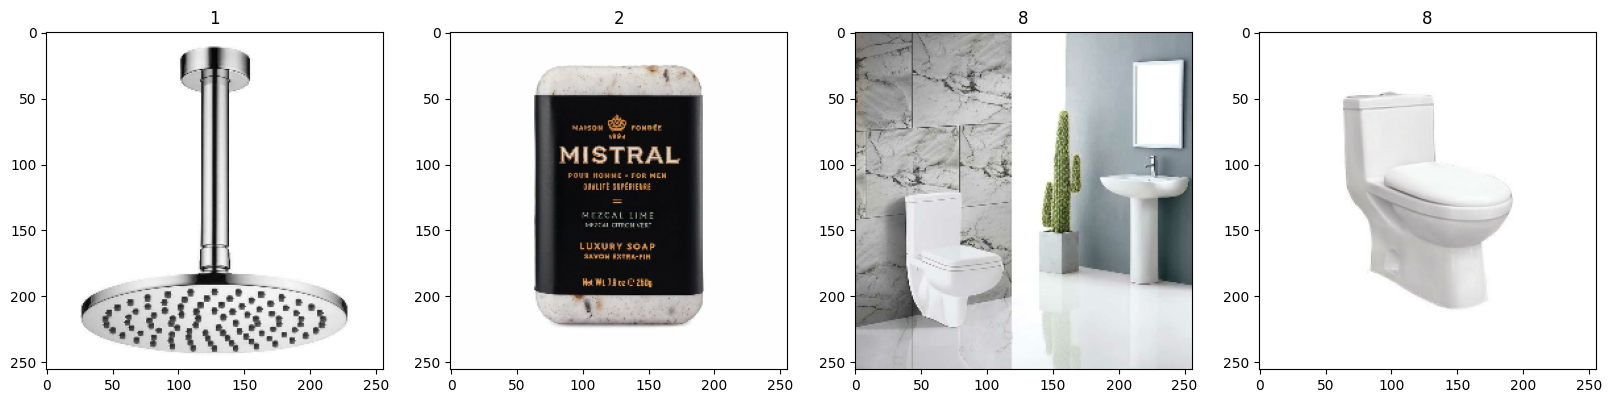

In [23]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

#### Preprocess

In [24]:
data = data.map(lambda x, y: (x/255, y))
scaled_iterator = data.as_numpy_iterator()
batch = scaled_iterator.next()

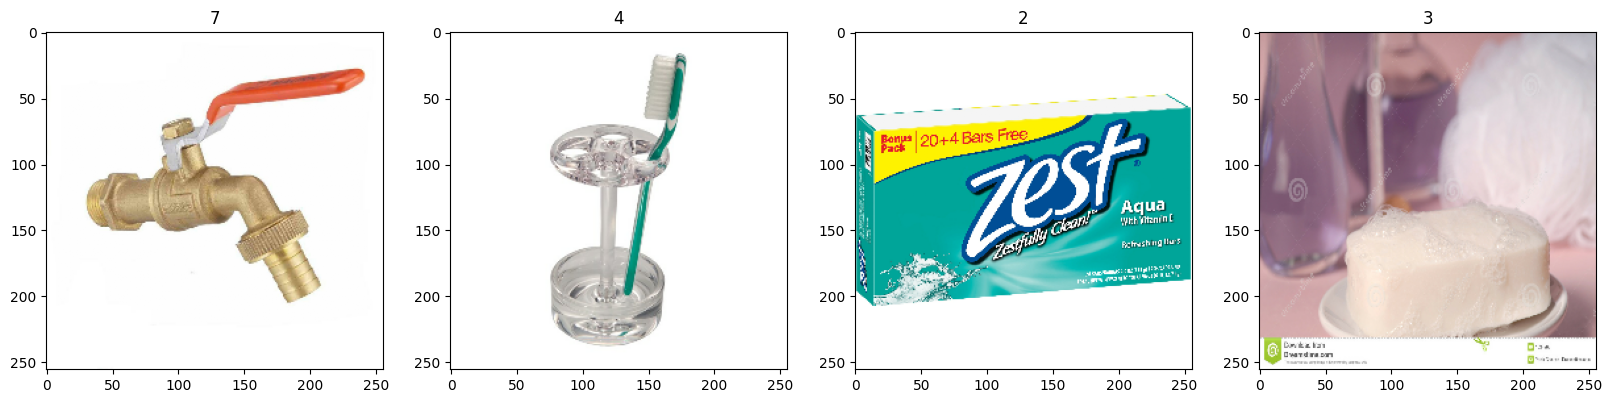

In [25]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

#### Split

In [26]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2) + 1
test_size = int(len(data)*.1) + 1

In [27]:
train_data = data.take(train_size)
val_data = data.skip(train_size).take(val_size)
tets_data = data.skip(train_size + val_size).take(test_size)

#### Model

In [28]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    MaxPooling2D(),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(9, activation='softmax')  
])

In [ ]:
# model = Sequential()

# model.add(Input(shape=(256, 256, 3)))
# model.add(RandomFlip("horizontal"))
# model.add(RandomRotation(0.2))
# model.add(Conv2D(32, (3,3), 1, activation='relu'))
# model.add(MaxPooling2D())
# model.add(Conv2D(64, (3,3), 1, activation='relu'))
# model.add(MaxPooling2D())
# model.add(Conv2D(64, (3,3), 1, activation='relu'))
# model.add(MaxPooling2D())
# model.add(Flatten())
# model.add(Dense(256, activation='relu'))
# model.add(Dense(9, activation='softmax'))

In [11]:
model.compile('adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,978,889 (121.99 MB)

 Trainable params: 8,391,177 (32.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [2]:
print(tf.config.list_physical_devices('GPU'))

[]


In [3]:
!export LD_LIBRARY_PATH=$(python -c 'import os, site; print(":".join([os.path.join(site.getsitepackages()[0], "nvidia", lib, "lib") for lib in ["cublas", "cudnn", "cufft", "curand", "cusolver", "cusparse", "nccl", "nvjitlink"]]))'):$LD_LIBRARY_PATH

In [1]:
import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1780854641.862959    6983 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
# import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


In [29]:
with tf.device('/GPU:0'):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        MaxPooling2D(),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(9, activation='softmax')  
    ])

    model.compile('adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
    model.summary()
    
    hist = model.fit(train_data, epochs=20, validation_data=val_data)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,978,889 (121.99 MB)

 Trainable params: 8,391,177 (32.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

...

158/158 ━━━━━━━━━━━━━━━━━━━━ 43s 270ms/step - accuracy: 0.5437 - loss: 1.3216 - val_accuracy: 0.4416 - val_loss: 1.6924
Epoch 11/20
 82/158 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.5798 - loss: 1.2759

Corrupt JPEG data: premature end of data segment


158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5721 - loss: 1.2854

Corrupt JPEG data: premature end of data segment


: 

#### Initiate Dagshub

In [15]:
import dagshub
import mlflow

mlflow.set_tracking_uri('https://dagshub.com/noobPeople/MLOps-Common-Object-Bathroom-Classification.mlflow')
dagshub.init(repo_owner='noobPeople', repo_name='MLOps-Common-Object-Bathroom-Classification', mlflow=True)

mlflow.set_experiment('CNN Baseline Optimum Setting')

Accessing as noobPeople

Initialized MLflow to track repo "noobPeople/MLOps-Common-Object-Bathroom-Classification"

Repository noobPeople/MLOps-Common-Object-Bathroom-Classification initialized!

<Experiment: artifact_location='mlflow-artifacts:/3ca92474d4394c008becb33088820d9b', creation_time=1776875590049, experiment_id='0', last_update_time=1776875590049, lifecycle_stage='active', name='CNN Baseline Optimum Setting', tags={}, trace_location=None, workspace='default'>

In [16]:
import logging
import time

# Configure Logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logging.info('Starting MLFlow...')

with mlflow.start_run(run_name='train_18'):
    start_time = time.time()

    try:
        logging.info("Preprocessing parameters...")
        mlflow.log_param('image size', '(256, 256)')
        mlflow.log_param('color mode', 'rgb')
        mlflow.log_param('epochs', '10')
        mlflow.log_param('regularization', 'no')
        mlflow.log_param('augmentation', 'no')
        mlflow.log_param('dropout', 'no')
        mlflow.log_param('conv2d layer', '-')
        mlflow.log_param('maxpooling2d layer', '1')
        mlflow.log_param('model', 'ResNet50')

        logging.info('Start training')
        hist = model.fit(train_data, epochs=10, validation_data=val_data)
        logging.info('Finish Training')

        logging.info('Start predict')
        pre = Precision()
        re = Recall()
        acc = SparseCategoricalAccuracy() 

        for batch in tets_data.as_numpy_iterator():
            X, y = batch
            yhat = model.predict(X)
            y_pred_classes = np.argmax(yhat, axis=1)
            
            # Update state
            # Catatan: Precision & Recall defaultnya untuk binary. 
            # Untuk multi-class murni, biasanya kita melihat akurasi atau 
            # menggunakan metrik eksternal seperti sklearn.
            pre.update_state(y, y_pred_classes)
            re.update_state(y, y_pred_classes)
            acc.update_state(y, yhat) # SparseCategoricalAccuracy butuh yhat asli
        logging.info('Finish predict')

        logging.info('Logging evaluation metrics')
        mlflow.log_metric('prediction', pre.result().numpy())
        mlflow.log_metric('recall', re.result().numpy())
        mlflow.log_metric('accuracy', acc.result().numpy())

        logging.info('Saving model')
        mlflow.tensorflow.log_model(model, 'model')

        end_time = time.time()
        logging.info(f'model training and logging completed in {end_time - start_time:.2f} seconds')

        logging.info(f'prediction {pre.result().numpy()}')
        logging.info(f'recall {re.result().numpy()}')
        logging.info(f'accuracy {acc.result().numpy()}')

    except Exception as e:
        logging.error('An error occured: {e}', exc_info=True)

2026-05-12 16:51:42,477 - INFO - Starting MLFlow...
2026-05-12 16:51:43,275 - INFO - Preprocessing parameters...
2026-05-12 16:51:45,888 - INFO - Start training


Epoch 1/10


2026-05-12 16:51:47,255 - ERROR - An error occured: {e}
Traceback (most recent call last):
  File "C:\Users\Zakky\AppData\Local\Temp\ipykernel_10872\526973418.py", line 24, in <module>
    hist = model.fit(train_data, epochs=10, validation_data=val_data)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Porto\MLOps-COB Classification\.venv\Lib\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "d:\Porto\MLOps-COB Classification\.venv\Lib\site-packages\keras\src\backend\tensorflow\nn.py", line 1233, in sparse_categorical_crossentropy
    raise ValueError(
ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(None,), output.shape=(None, 4, 4, 9)


🏃 View run train_18 at: https://dagshub.com/noobPeople/MLOps-Common-Object-Bathroom-Classification.mlflow/#/experiments/0/runs/420ed0acad9344ed987ff7230002e326
🧪 View experiment at: https://dagshub.com/noobPeople/MLOps-Common-Object-Bathroom-Classification.mlflow/#/experiments/0


#### Plot

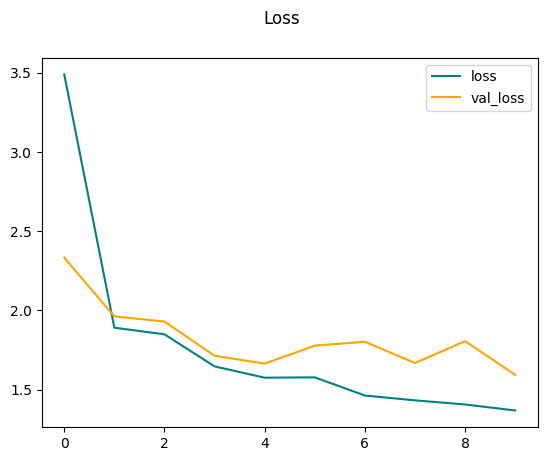

In [17]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss')
plt.legend()
plt.show()

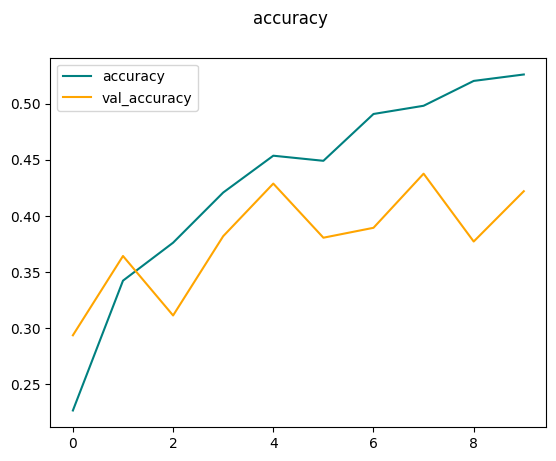

In [18]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('accuracy')
plt.legend()
plt.show()